# Garbage classification Final Submission
---
## Project Description
>In this project, we aim to develop a sophisticated **garbage classification** system leveraging the **EfficientNetV2S** architecture. Our primary dataset serves as a foundation for building models that can eventually automate waste segregation, a critical step in optimizing recycling and waste management, ultimately aiding in environmental conservation.

**Goal:** To develop an accurate and efficient garbage classification model using transfer learning for automated waste sorting.
## Changes made to the code 
- Increased number of epochs from 15 to 20
- Removed Dropout layer
## Comparsion Pre-trained models
| Pre-trained model | Accuracy | No. of epochs|
|-------------------|----------|--------------|
| EfficientNetV2S   | ~88%     | 30           |
|MobileNetV2        | ~45%     | 10           |
|EfficientNetV2B2   | ~91%     | 20           |
---

## Core libraries
- tensorflow: For deep learning model building and training.
- numpy: For numerical operations and array manipulation.
- matplotlib.pyplot: For plotting training curves and results.

In [2]:
import numpy as np #managing and manupulating arrays 
import matplotlib.pyplot as plt #plotting graph and displaying images with labels
import seaborn as sns #for extra features on top of matplotlib 
import tensorflow as tf #core computational task for deep learning neutral networks
from tensorflow import keras #functional API to simplify model building
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetV2B2 #base model
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import gradio as gr #to provide web interface


In [2]:
# Dataset configuration
dir_path = r"GarbageClassification"
image_size = (124, 124)
batch_size = 32
seed = 42


In [3]:
# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    dir_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    shuffle=True,
    image_size=image_size,
    batch_size=batch_size
)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dir_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    shuffle=True,
    image_size=image_size,
    batch_size=batch_size
)
# Get class names
class_names = train_ds.class_names


Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [5]:
# Get the total number of batches in the validation dataset
val_batches = tf.data.experimental.cardinality(val_ds)

# Split the validation dataset into two equal parts:
# First half becomes the test dataset
test_ds = val_ds.take(val_batches // 2)

# Second half remains as the validation dataset
val_dat = val_ds.skip(val_batches // 2)

# Optimize test dataset by caching and prefetching to improve performance
test_ds_eval = test_ds.cache().prefetch(tf.data.AUTOTUNE)

### Visualization of the images from train dataset

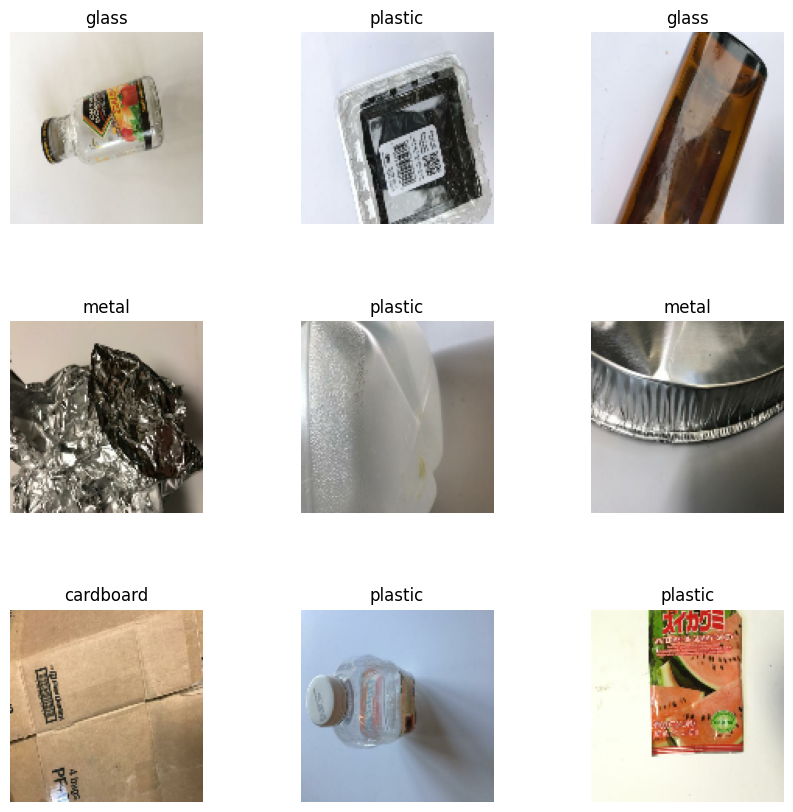

In [6]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

### train, validation and  test datasets class distributions plotting, to show class imbalance over datasets

In [7]:
def labels_count(dataset):
  total = 0
  labels_count = {class_names[i]: 0 for i in range(len(class_names))}
  for _ , labels in dataset:
    for label in labels.numpy():
      labels_count[class_names[label]]+=1
      total+=1
  for i in labels_count:
    labels_count[i] = round((labels_count[i]/total)* 100, 2)
  return labels_count

In [8]:
def simple_bar_plot(dist, title):
  plt.bar(dist.keys() , dist.values() , color = 'cornflowerblue')
  plt.title(title)
  plt.ylabel("percentage (%)")
  plt.xticks(rotation = 45)
  plt.ylim(0, 100)
  #plt.tight_layout()
  plt.show()

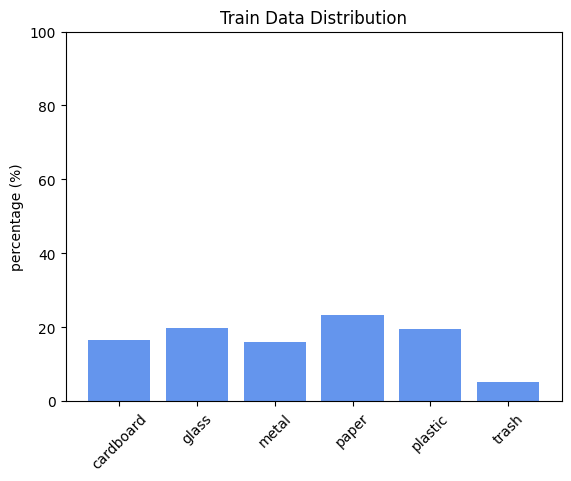

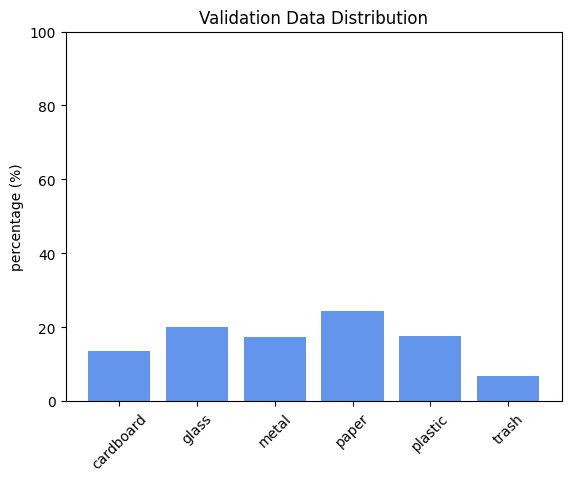

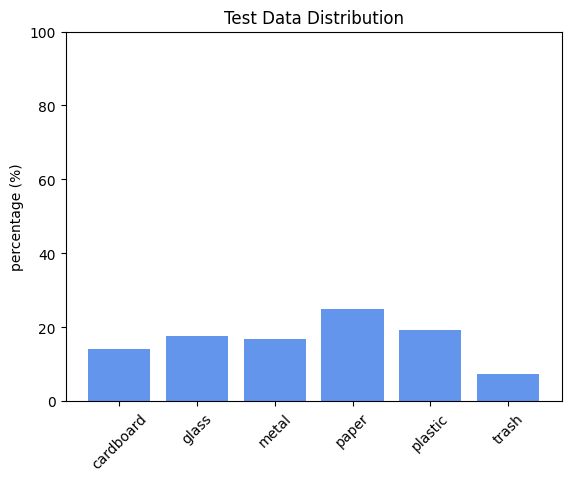

In [9]:
train_dist = labels_count(train_ds)
val_dist = labels_count(val_ds)
test_dist = labels_count(test_ds)
simple_bar_plot(train_dist, "Train Data Distribution")
simple_bar_plot(val_dist, "Validation Data Distribution")
simple_bar_plot(test_dist, "Test Data Distribution")

In [10]:
#  Define data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [11]:
  # Preprocess all datasets
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls = tf.data.AUTOTUNE)


In [12]:
# Optimize dataset performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


### Balance class weights through compute_class_weight function

### 🛠️ Addressing Imbalance Using Class Weights:

To tackle our imbalanced image dataset, we'll utilize **class weights**. These weights assign more importance to underrepresented classes during training. The weights are computed inversely proportional to class frequencies using utilities like `compute_class_weight` from **scikit-learn**, based on the distribution of images in each class. The formula is:

$$
\text{weight(class)} = \frac{\text{total samples}}{\text{number of classes} \times \text{samples in that class}}
$$

These computed weights are then passed to the model.


In [13]:
# Calculate class weights to handle potential imbalance
labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_weights = compute_class_weight(
                                        'balanced',
                                        classes=np.unique(labels),
                                        y=labels
                                    )
class_weights = dict(enumerate(class_weights))


In [14]:
print(train_dist)
print(class_weights)

{'cardboard': 16.52, 'glass': 19.73, 'metal': 15.92, 'paper': 23.29, 'plastic': 19.44, 'trash': 5.09}
{0: 1.0089820359281436, 1: 0.8446115288220551, 2: 1.046583850931677, 3: 0.7154989384288747, 4: 0.8575063613231552, 5: 3.2718446601941746}


In [15]:
# Define the model
base_model = EfficientNetV2B2(weights='imagenet', include_top=False, input_shape=(124, 124, 3))
base_model.trainable = True
for layer in base_model.layers[:100]:
  layers.trainable = False


In [16]:
model = keras.Sequential([
    layers.Input(shape = (124 ,124 ,3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(6, activation='softmax')
])


In [17]:

# Compile with a smaller learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Define callbacks
early = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [19]:

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size = 32,
    class_weight=class_weights,
    callbacks=[early]
)

Epoch 1/20
64/64 [==============================] - 66s 679ms/step - loss: 1.5183 - accuracy: 0.4322 - val_loss: 1.2296 - val_accuracy: 0.6198
Epoch 2/20
64/64 [==============================] - 40s 620ms/step - loss: 0.9670 - accuracy: 0.7087 - val_loss: 0.9088 - val_accuracy: 0.7030
Epoch 3/20
64/64 [==============================] - 40s 629ms/step - loss: 0.6517 - accuracy: 0.7957 - val_loss: 0.7313 - val_accuracy: 0.7485
Epoch 4/20
64/64 [==============================] - 41s 631ms/step - loss: 0.5096 - accuracy: 0.8447 - val_loss: 0.6161 - val_accuracy: 0.8000
Epoch 5/20
64/64 [==============================] - 40s 629ms/step - loss: 0.3873 - accuracy: 0.8734 - val_loss: 0.5651 - val_accuracy: 0.8139
Epoch 6/20
64/64 [==============================] - 39s 613ms/step - loss: 0.3391 - accuracy: 0.8843 - val_loss: 0.5266 - val_accuracy: 0.8119
Epoch 7/20
64/64 [==============================] - 40s 616ms/step - loss: 0.2821 - accuracy: 0.9055 - val_loss: 0.4683 - val_accuracy: 0.8297

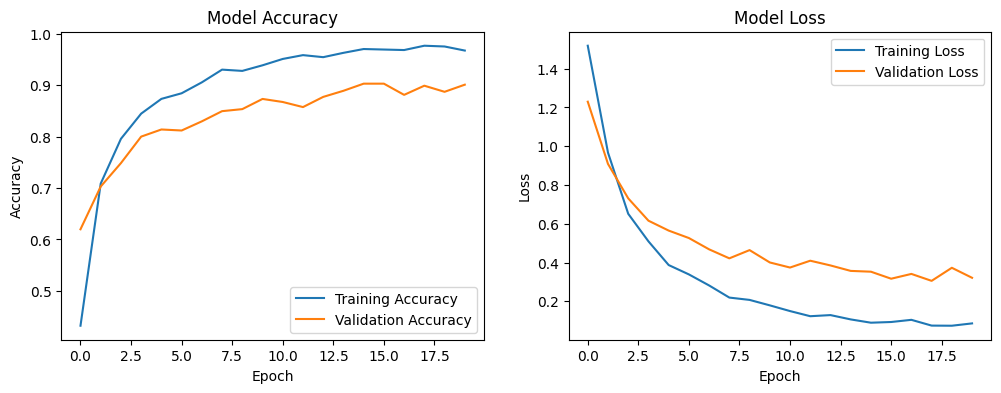

In [20]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Model evaluation 

In [21]:
loss , accuracy = model.evaluate(test_ds_eval)
print(f'Test accuracy is {accuracy:.4f}, Test loss is {loss:.4f}')

8/8 [==============================] - 0s 33ms/step - loss: 0.3254 - accuracy: 0.9062
Test accuracy is 0.9062, Test loss is 0.3254


## 

## Confusion matrix

In [22]:
# Extract true labels from all batches in the test dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds_eval], axis=0)  # Convert Tensor labels to NumPy array and concatenate them

# Get predictions as probabilities from the model
y_pred_probs = model.predict(test_ds_eval)  # Predict class probabilities for each sample in the test dataset

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)  # Select the class with the highest probability for each sample

# Compute the confusion matrix to evaluate classification performance
cm = confusion_matrix(y_true, y_pred)  # Generate confusion matrix comparing true labels to predicted labels

# Print metrics to assess model performance
print(cm)  # Display confusion matrix
print(classification_report(y_true, y_pred))  # Print precision, recall, and F1-score for each class


8/8 [==============================] - 2s 28ms/step
[[38  0  0  1  0  0]
 [ 0 41  6  0  1  0]
 [ 0  1 45  0  0  1]
 [ 3  0  1 53  0  5]
 [ 1  0  3  0 35  1]
 [ 0  0  0  0  0 20]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        39
           1       0.98      0.85      0.91        48
           2       0.82      0.96      0.88        47
           3       0.98      0.85      0.91        62
           4       0.97      0.88      0.92        40
           5       0.74      1.00      0.85        20

    accuracy                           0.91       256
   macro avg       0.90      0.92      0.90       256
weighted avg       0.92      0.91      0.91       256



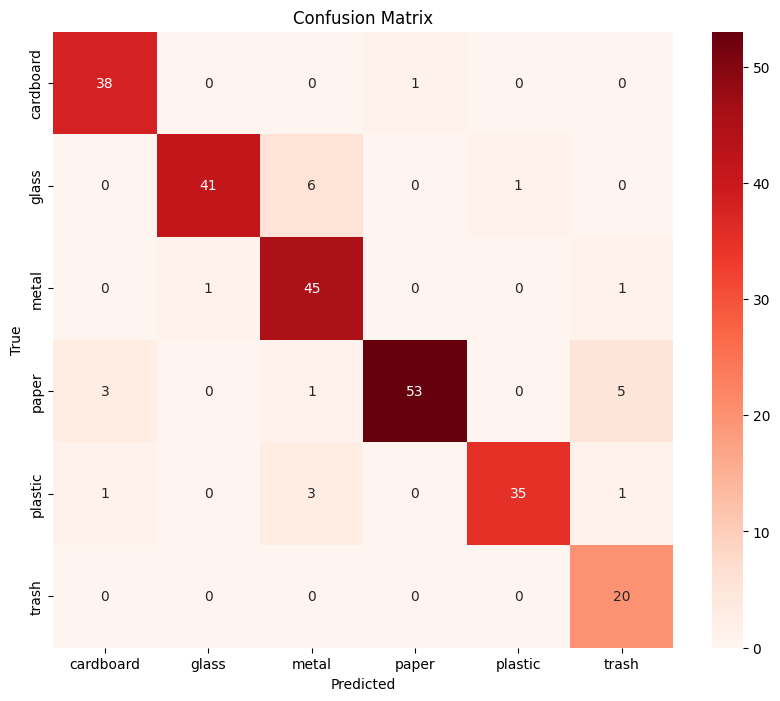

In [23]:
plt.figure(figsize=(10,8))  # Set figure size for better visualization

sns.heatmap(cm, annot=True, fmt='d',  # Create heatmap using confusion matrix
            xticklabels=class_names,  # Set class names for x-axis (predicted labels)
            yticklabels=class_names,  # Set class names for y-axis (true labels)
            cmap='Reds')  # Use a blue colormap for better contrast

plt.xlabel('Predicted')  # Label x-axis as Predicted classes
plt.ylabel('True')  # Label y-axis as True classes
plt.title('Confusion Matrix')  # Add title to the heatmap
plt.show()  # Display the plot

## Testing model

1/1 [==============================] - 1s 1s/step


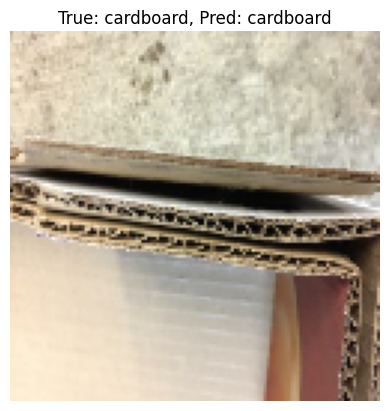

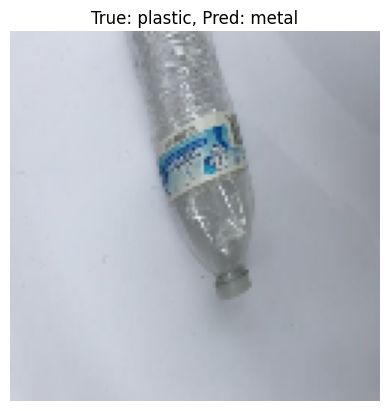

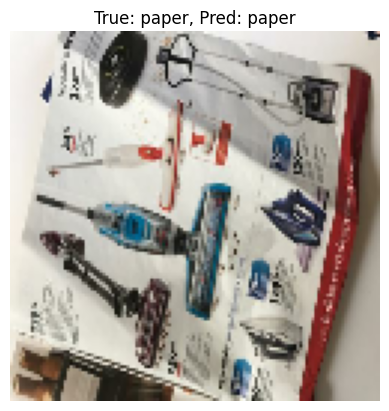

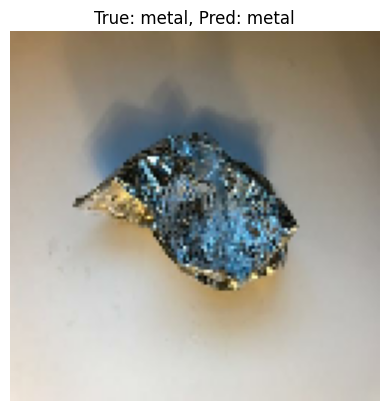

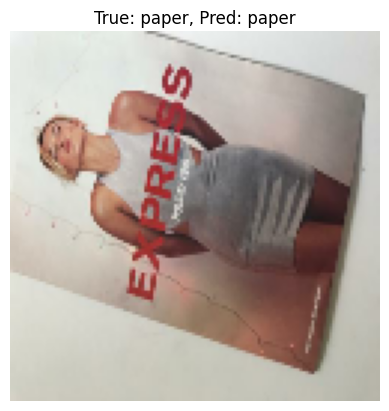

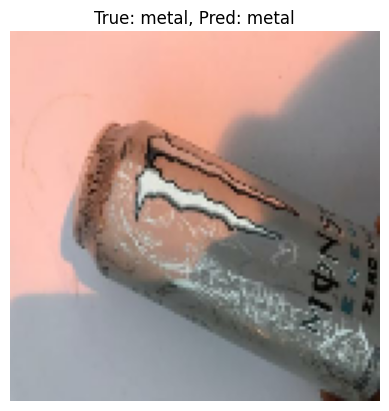

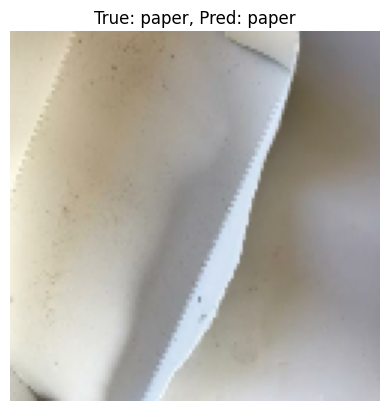

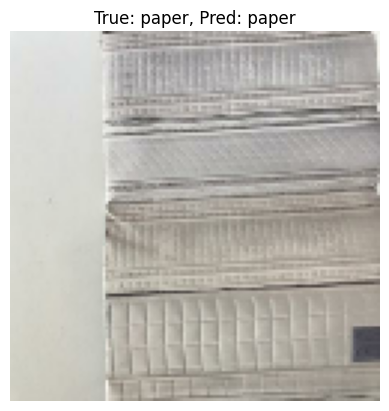

In [24]:

# Take one batch of images and labels from the test dataset for evaluation
for images, labels in test_ds_eval.take(1):

    # Generate predictions for the batch of images
    predictions = model.predict(images)

    # Get the predicted class index for each image
    pred_labels = tf.argmax(predictions, axis=1)

    # Loop through the first 8 images in the batch
    for i in range(8):
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert and display image
        plt.title(f"True: {class_names[labels[i]]}, Pred: {class_names[pred_labels[i]]}")  # Show actual and predicted class
        plt.axis("off")  # Hide axes for better visualization
        plt.show()  # Display the image with title

# Deployment model

In [25]:
model.save('garbage_classification_model.keras')
model = tf.keras.models.load_model('garbage_classification_model.keras')

In [35]:

# Gradio interface with correct resizing
def classify_image(img):
    if img is None:
        return "Please upload an image."
    img = img.resize((124, 124))
    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[0][predicted_class_index]
    return f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f})"


In [38]:
iface = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Garbage Classification",
    description="Upload an image to classify it into one of 6 garbage categories."
)

# Launch the interface
iface.launch(share=False)

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


1/1 [==============================] - 0s 34ms/step
